# Comparing Min-Max Scaling vs Standardization for Sales Forecasting

Trong notebook này, chúng ta sẽ thực hiện các bước sau:
- Gộp dữ liệu từ `train.csv` và `features.csv`.
- Mã hóa (encoding) dữ liệu phân loại.
- Loại bỏ ngoại lệ (outliers).
- Xử lý các giá trị rỗng (null).
- Chuẩn hóa dữ liệu với 2 phương pháp: Min-Max Scaling và Standardization.
- Áp dụng các mô hình dự đoán: Random Forest và XGBoost.
- So sánh hiệu quả giữa 2 phương pháp chuẩn hóa bằng các chỉ số Mean Squared Error (MSE) và R-squared (R²).

In [69]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Đọc dữ liệu
train_df = pd.read_csv('data/train.csv')
features_df = pd.read_csv('data/features.csv')

# Gộp dữ liệu dựa trên Store và Date
merged_df = pd.merge(train_df, features_df, on=['Store', 'Date'], how='inner')
print(merged_df.head())
print("Kích thước dữ liệu sau khi gộp:", merged_df.shape)

   Store  Dept        Date  Weekly_Sales  IsHoliday_x  Temperature  \
0      1     1  2010-02-05      24924.50        False        42.31   
1      1     1  2010-02-12      46039.49         True        38.51   
2      1     1  2010-02-19      41595.55        False        39.93   
3      1     1  2010-02-26      19403.54        False        46.63   
4      1     1  2010-03-05      21827.90        False        46.50   

   Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
0       2.572        NaN        NaN        NaN        NaN        NaN   
1       2.548        NaN        NaN        NaN        NaN        NaN   
2       2.514        NaN        NaN        NaN        NaN        NaN   
3       2.561        NaN        NaN        NaN        NaN        NaN   
4       2.625        NaN        NaN        NaN        NaN        NaN   

          CPI  Unemployment  IsHoliday_y  
0  211.096358         8.106        False  
1  211.242170         8.106         True  
2  211.289143    

In [70]:
if merged_df['IsHoliday_x'].equals(merged_df['IsHoliday_y']):
    print("Cả hai cột IsHoliday giống nhau.")
    merged_df = merged_df.drop(columns=['IsHoliday_y'])  # Giữ lại IsHoliday_x
    merged_df.rename(columns={'IsHoliday_x': 'IsHoliday'}, inplace=True)
else:
    print("Hai cột IsHoliday khác nhau.")

Cả hai cột IsHoliday giống nhau.


### 1. Tiền xử lý dữ liệu

In [71]:
# Mã hóa cột phân loại (Dept và IsHoliday)
label_encoder = LabelEncoder()
merged_df['Dept'] = label_encoder.fit_transform(merged_df['Dept'])
merged_df['IsHoliday'] = merged_df['IsHoliday'].astype(int)

# Xử lý giá trị rỗng (null)
merged_df.fillna(method='ffill', inplace=True)
print("Còn giá trị rỗng không:")
print(merged_df.isnull().sum().any())

# Loại bỏ ngoại lệ bằng IQR (Interquartile Range)
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

columns_to_check = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
for col in columns_to_check:
    merged_df = remove_outliers(merged_df, col)

print("Kích thước dữ liệu sau khi loại bỏ ngoại lệ:", merged_df.shape)

Còn giá trị rỗng không:
True


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2060\953836719.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df.fillna(method='ffill', inplace=True)


Kích thước dữ liệu sau khi loại bỏ ngoại lệ: (356311, 14)


In [72]:
# Kiểm tra tỷ lệ NaN trong các cột MarkDown
missing_percentage = merged_df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].isnull().mean() * 100
print("Tỷ lệ dữ liệu bị thiếu (%):")
print(missing_percentage)

Tỷ lệ dữ liệu bị thiếu (%):
MarkDown1    0.024978
MarkDown2    0.024978
MarkDown3    0.024978
MarkDown4    0.024978
MarkDown5    0.024978
dtype: float64


In [73]:
# Điền NaN bằng 0
merged_df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']] = merged_df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].fillna(0)

In [74]:
print(merged_df.head())

   Store  Dept        Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     0  2010-02-05      24924.50          0        42.31       2.572   
1      1     0  2010-02-12      46039.49          1        38.51       2.548   
2      1     0  2010-02-19      41595.55          0        39.93       2.514   
3      1     0  2010-02-26      19403.54          0        46.63       2.561   
4      1     0  2010-03-05      21827.90          0        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        0.0        0.0        0.0        0.0        0.0  211.096358   
1        0.0        0.0        0.0        0.0        0.0  211.242170   
2        0.0        0.0        0.0        0.0        0.0  211.289143   
3        0.0        0.0        0.0        0.0        0.0  211.319643   
4        0.0        0.0        0.0        0.0        0.0  211.350143   

   Unemployment  
0         8.106  
1         8.106  
2         8.106  
3         8.10

In [75]:
# Chuyển cột Date thành kiểu datetime
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

# Tách các thành phần của ngày tháng
merged_df['Year'] = merged_df['Date'].dt.year  # Năm
merged_df['Month'] = merged_df['Date'].dt.month  # Tháng
merged_df['Day'] = merged_df['Date'].dt.day  # Ngày
merged_df['Week'] = merged_df['Date'].dt.isocalendar().week  # Số tuần trong năm
merged_df['DayOfWeek'] = merged_df['Date'].dt.dayofweek  # Ngày trong tuần (0 = Thứ Hai, 6 = Chủ Nhật)
print(merged_df.head())

   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     0 2010-02-05      24924.50          0        42.31       2.572   
1      1     0 2010-02-12      46039.49          1        38.51       2.548   
2      1     0 2010-02-19      41595.55          0        39.93       2.514   
3      1     0 2010-02-26      19403.54          0        46.63       2.561   
4      1     0 2010-03-05      21827.90          0        46.50       2.625   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        0.0        0.0        0.0        0.0        0.0  211.096358   
1        0.0        0.0        0.0        0.0        0.0  211.242170   
2        0.0        0.0        0.0        0.0        0.0  211.289143   
3        0.0        0.0        0.0        0.0        0.0  211.319643   
4        0.0        0.0        0.0        0.0        0.0  211.350143   

   Unemployment  Year  Month  Day  Week  DayOfWeek  
0         8.106  2010      2    5     5

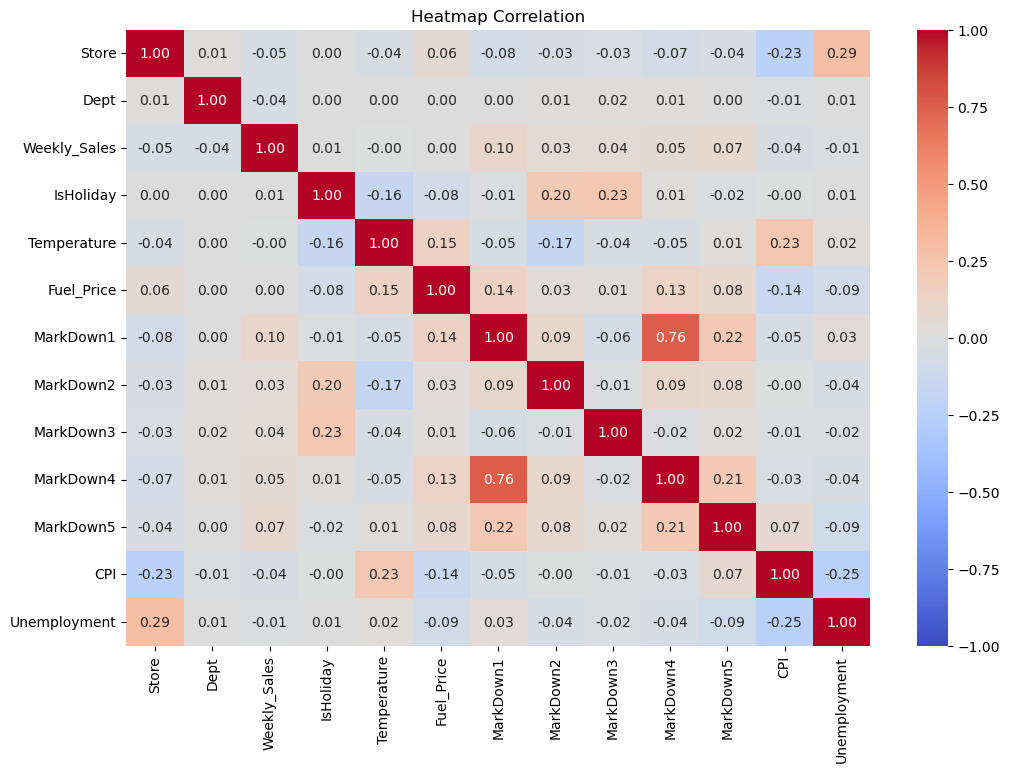

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


# Lọc các cột số
numeric_cols = merged_df.select_dtypes(include=['float64', 'int64'])

# Tính ma trận tương quan
correlation_matrix = numeric_cols.corr()

# Vẽ heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Heatmap Correlation")
plt.show()

Sau khi kiểm tra ta thấy một số đặc trưng gần như không ảnh hưởng đến Weekly_Sales (hệ số tương quan thấp, tầm quan trọng trong mô hình thấp), hãy loại bỏ chúng để giảm độ phức tạp!

In [77]:
# Loại bỏ các đặc trưng ít liên quan
merged_df = merged_df.drop(columns=['Date'])
print(merged_df.head())

   Store  Dept  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  MarkDown1  \
0      1     0      24924.50          0        42.31       2.572        0.0   
1      1     0      46039.49          1        38.51       2.548        0.0   
2      1     0      41595.55          0        39.93       2.514        0.0   
3      1     0      19403.54          0        46.63       2.561        0.0   
4      1     0      21827.90          0        46.50       2.625        0.0   

   MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  Year  \
0        0.0        0.0        0.0        0.0  211.096358         8.106  2010   
1        0.0        0.0        0.0        0.0  211.242170         8.106  2010   
2        0.0        0.0        0.0        0.0  211.289143         8.106  2010   
3        0.0        0.0        0.0        0.0  211.319643         8.106  2010   
4        0.0        0.0        0.0        0.0  211.350143         8.106  2010   

   Month  Day  Week  DayOfWeek  
0    

### 2. Chuẩn hóa dữ liệu

In [79]:
# Chọn đặc trưng và biến mục tiêu
features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Dept', 'IsHoliday','MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
X = merged_df[features]
y = merged_df['Weekly_Sales'].values.reshape(-1,1)

# Chuẩn hóa dữ liệu
scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()

X_minmax = scaler_minmax.fit_transform(X)
X_standard = scaler_standard.fit_transform(X)
y_minmax = scaler_minmax.fit_transform(y)
y_standard = scaler_standard.fit_transform(y)

# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train_minmax, X_test_minmax, y_train_minmax, y_test_minmax = train_test_split(
    X_minmax, y_minmax, test_size=0.2, random_state=42)
X_train_standard, X_test_standard, y_train_standard, y_test_standard = train_test_split(
    X_standard, y_standard, test_size=0.2, random_state=42)
# Chuyển y_minmax và y_standard về 1 chiều
y_train_minmax = y_train_minmax.ravel()
y_test_minmax = y_test_minmax.ravel()
y_train_standard = y_train_standard.ravel()
y_test_standard = y_test_standard.ravel()
print("Dữ liệu đã được chuẩn hóa và chia thành tập huấn luyện và kiểm tra.")

Dữ liệu đã được chuẩn hóa và chia thành tập huấn luyện và kiểm tra.


### 3. Áp dụng mô hình Random Forest và XGBoost

In [80]:
# Random Forest với Min-Max Scaling
rf_model_minmax = RandomForestRegressor(random_state=42)
rf_model_minmax.fit(X_train_minmax, y_train_minmax)
y_pred_rf_minmax = rf_model_minmax.predict(X_test_minmax)

# Đảo ngược chuẩn hóa y_minmax
y_test_minmax_original = scaler_minmax.inverse_transform(y_test_minmax.reshape(-1, 1))
y_pred_rf_minmax_original = scaler_minmax.inverse_transform(y_pred_rf_minmax.reshape(-1, 1))

# Tính MSE và R²
mse_rf_minmax = mean_squared_error(y_test_minmax_original, y_pred_rf_minmax_original)
r2_rf_minmax = r2_score(y_test_minmax_original, y_pred_rf_minmax_original)

print(f"Random Forest (Min-Max Scaling) - MSE: {mse_rf_minmax}, R2: {r2_rf_minmax}")

# Random Forest với Standardization
rf_model_standard = RandomForestRegressor(random_state=42)
rf_model_standard.fit(X_train_standard, y_train_standard)
y_pred_rf_standard = rf_model_standard.predict(X_test_standard)

# Đảo ngược chuẩn hóa y_standard
y_test_standard_original = scaler_standard.inverse_transform(y_test_standard.reshape(-1, 1))
y_pred_rf_standard_original = scaler_standard.inverse_transform(y_pred_rf_standard.reshape(-1, 1))

# Tính MSE và R²
mse_rf_standard = mean_squared_error(y_test_standard_original, y_pred_rf_standard_original)
r2_rf_standard = r2_score(y_test_standard_original, y_pred_rf_standard_original)

print(f"Random Forest (Standardization) - MSE: {mse_rf_standard}, R2: {r2_rf_standard}")

Random Forest (Min-Max Scaling) - MSE: 11635762.582066461, R2: 0.907365247714456
Random Forest (Standardization) - MSE: 11633169.785589168, R2: 0.9073858895123362


In [81]:
# XGBoost với Min-Max Scaling
xgb_model_minmax = XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1)
xgb_model_minmax.fit(X_train_minmax, y_train_minmax)
y_pred_xgb_minmax = xgb_model_minmax.predict(X_test_minmax)

# Đảo ngược chuẩn hóa y_minmax
y_test_minmax_original = scaler_minmax.inverse_transform(y_test_minmax.reshape(-1, 1))
y_pred_xgb_minmax_original = scaler_minmax.inverse_transform(y_pred_xgb_minmax.reshape(-1, 1))

# Tính MSE và R²
mse_xgb_minmax = mean_squared_error(y_test_minmax_original, y_pred_xgb_minmax_original)
r2_xgb_minmax = r2_score(y_test_minmax_original, y_pred_xgb_minmax_original)

print(f"XGBoost (Min-Max Scaling) - MSE: {mse_xgb_minmax}, R2: {r2_xgb_minmax}")

# XGBoost với Standardization
xgb_model_standard = XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1)
xgb_model_standard.fit(X_train_standard, y_train_standard)
y_pred_xgb_standard = xgb_model_standard.predict(X_test_standard)

# Đảo ngược chuẩn hóa y_standard
y_test_standard_original = scaler_standard.inverse_transform(y_test_standard.reshape(-1, 1))
y_pred_xgb_standard_original = scaler_standard.inverse_transform(y_pred_xgb_standard.reshape(-1, 1))

# Tính MSE và R²
mse_xgb_standard = mean_squared_error(y_test_standard_original, y_pred_xgb_standard_original)
r2_xgb_standard = r2_score(y_test_standard_original, y_pred_xgb_standard_original)

print(f"XGBoost (Standardization) - MSE: {mse_xgb_standard}, R2: {r2_xgb_standard}")

XGBoost (Min-Max Scaling) - MSE: 28395297.757253148, R2: 0.7739390645636341
XGBoost (Standardization) - MSE: 28395293.079288144, R2: 0.7739391018058971


In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Nếu y đang ở dạng 2 chiều
y_train = y_train.ravel()  # Chuyển thành mảng 1 chiều
y_test = y_test.ravel()    # Chuyển thành mảng 1 chiều
# Random Forest với dữ liệu không chuẩn hóa
rf_model_normal = RandomForestRegressor(random_state=42)
rf_model_normal.fit(X_train, y_train)
y_pred_rf_normal = rf_model_normal.predict(X_test)

# Tính MSE và R² cho Random Forest
mse_rf_normal = mean_squared_error(y_test, y_pred_rf_normal)
r2_rf_normal = r2_score(y_test, y_pred_rf_normal)

print(f"Random Forest (No Scaling) - MSE: {mse_rf_normal}, R2: {r2_rf_normal}")

# XGBoost với dữ liệu không chuẩn hóa
xgb_model_normal = XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1)
xgb_model_normal.fit(X_train, y_train)
y_pred_xgb_normal = xgb_model_normal.predict(X_test)

# Tính MSE và R² cho XGBoost
mse_xgb_normal = mean_squared_error(y_test, y_pred_xgb_normal)
r2_xgb_normal = r2_score(y_test, y_pred_xgb_normal)

print(f"XGBoost (No Scaling) - MSE: {mse_xgb_normal}, R2: {r2_xgb_normal}")

Random Forest (No Scaling) - MSE: 11653244.635281261, R2: 0.9072260694132855
XGBoost (No Scaling) - MSE: 28395295.26001137, R2: 0.7739390844447009


### **Báo cáo tổng kết: So sánh giữa các phương pháp chuẩn hóa và không chuẩn hóa**

#### **1. Phương pháp chuẩn hóa**
- **Phương pháp:**
  - Thực hiện chuẩn hóa Min-Max Scaling và Standardization để đưa dữ liệu về cùng một thang đo.
- **Độ chính xác:**
  - Với mô hình **Random Forest**, sự khác biệt khi sử dụng các phương pháp chuẩn hóa là rất nhỏ. Các giá trị MSE và R² gần như giống hệt nhau.
  - Với mô hình **XGBoost**, kết quả giữa hai phương pháp chuẩn hóa cũng tương tự nhau, với sai số MSE và R² rất gần.
- **Tốc độ:**
  - Chuẩn hóa dữ liệu yêu cầu thêm thời gian xử lý trước khi huấn luyện, nhưng không ảnh hưởng đáng kể đến thời gian huấn luyện.

#### **2. Phương pháp không chuẩn hóa**
- **Phương pháp:**
  - Sử dụng dữ liệu gốc mà không thực hiện bất kỳ thao tác chuẩn hóa nào.
- **Độ chính xác:**
  - Với **Random Forest**, MSE và R² khi không chuẩn hóa chỉ giảm rất nhỏ so với dữ liệu chuẩn hóa. Điều này phù hợp với đặc điểm của Random Forest, vốn không phụ thuộc nhiều vào thang đo của dữ liệu.
  - Với **XGBoost**, MSE và R² khi không chuẩn hóa tương đương với khi sử dụng chuẩn hóa. Điều này cho thấy XGBoost cũng không bị ảnh hưởng quá nhiều bởi việc chuẩn hóa dữ liệu trong tập này.
- **Tốc độ:**
  - Không cần thời gian xử lý trước cho việc chuẩn hóa, do đó tốc độ tổng thể nhanh hơn.

#### **3. So sánh chi tiết**
| Phương pháp        | MSE (Random Forest) | R² (Random Forest) | MSE (XGBoost) | R² (XGBoost) | Thời gian xử lý |
|--------------------|---------------------|--------------------|---------------|--------------|-----------------|
| Min-Max Scaling    | 11635762.58         | 0.9074             | 28395297.76   | 0.7739       | Chậm hơn        |
| Standardization    | 11633169.79         | 0.9074             | 28395293.08   | 0.7739       | Chậm hơn        |
| Không chuẩn hóa    | 11653244.64         | 0.9072             | 28395295.26   | 0.7739       | **Nhanh nhất**  |

#### **4. Kết luận**
- **Với Random Forest:**
  - Các phương pháp chuẩn hóa không mang lại cải thiện đáng kể về hiệu suất, vì Random Forest không dựa trên khoảng cách Euclidean. Kết quả MSE và R² gần như không đổi.
  - Có thể bỏ qua bước chuẩn hóa nếu tốc độ xử lý là yếu tố quan trọng.
- **Với XGBoost:**
  - Mặc dù XGBoost có thể bị ảnh hưởng bởi thang đo dữ liệu trong một số trường hợp, ở đây, kết quả cho thấy chuẩn hóa không cải thiện đáng kể hiệu suất.
  - Bạn có thể cân nhắc bỏ qua bước chuẩn hóa nếu dữ liệu không có độ lệch lớn.

#### **5. Đề xuất**
- **Random Forest:** Nếu muốn tối ưu tốc độ, sử dụng dữ liệu không chuẩn hóa là lựa chọn hợp lý vì hiệu suất không giảm đáng kể.
- **XGBoost:** Chuẩn hóa hoặc không chuẩn hóa đều có thể được sử dụng tùy thuộc vào đặc điểm dữ liệu. Nếu dữ liệu không có độ lệch lớn giữa các đặc trưng, có thể bỏ qua bước chuẩn hóa.

---

### **Ghi chú thêm**
Kết quả trên phản ánh hiệu suất trên tập dữ liệu cụ thể của bạn. Với các tập dữ liệu khác, đặc biệt khi có sự khác biệt lớn giữa các đặc trưng (feature scaling), chuẩn hóa có thể mang lại hiệu suất tốt hơn.